In [1]:
import numpy as np
import numpy.typing as npt
from matplotlib import pyplot as plt
import pandas as pd

# Data functions

In [ ]:
def create_clusters(num_clusters: int, num_points_per_cluster) -> npt.NDArray[np.float64]:
    """
    Generate a number of points that have membership to a given number of clusters.
    """
    clusters = np.zeros((num_clusters, num_points_per_cluster, 2))

    for cluster_idx in range(num_clusters):
        midpoint = np.random.uniform(-1, 1, 2)
        spread = np.random.uniform(0.025, 0.4)
        clusters[cluster_idx] = np.random.normal(midpoint, spread, (num_points_per_cluster,2))
    return clusters


def plot_clusters(clusters: npt.NDArray[np.float64]):
    """
    Visualize the points for each cluster.
    """
    fix, ax = plt.subplots(figsize=(4,4))
    for cluster_idx, cluster_points in enumerate(clusters):
        ax.scatter(*cluster_points.T, alpha=0.6, s=5, label=cluster_idx)
    ax.legend()
    ax.set_xlim((-1.5, 1.5))
    ax.set_ylim((-1.5, 1.5))
    plt.show()


def create_dataframe(clusters: npt.NDArray[np.float64]) -> pd.DataFrame:
    """
    Create a DataFrame of shuffled (x,y) points and hot-encoded clusters.
    """
    points = clusters.reshape((-1, 2))
    membership = np.repeat(np.arange(clusters.shape[0]), clusters.shape[1])
    df = pd.DataFrame(data={"x":points[:,0], "y":points[:,1], "cluster":membership})
    df_encoded = pd.get_dummies(df, columns=["cluster"])
    df_shuffled = df_encoded.sample(df_encoded.shape[0]).reset_index(drop=True)
    return df_shuffled

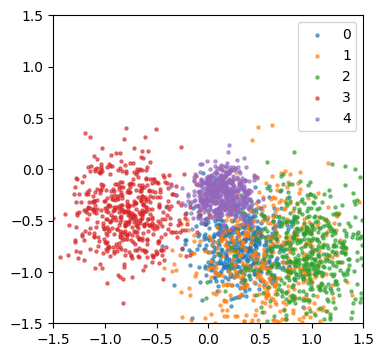

,x,y,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
0,0.301612,-0.485766,False,True,False,False,False
1,0.341975,-0.313831,False,False,False,False,True
2,-0.444024,-0.747214,True,False,False,False,False
3,0.572364,-0.669991,False,True,False,False,False
4,0.524817,-1.707349,False,True,False,False,False
...,...,...,...,...,...,...,...
2495,0.928625,-0.632409,False,False,True,False,False
2496,1.480684,-1.250499,False,False,True,False,False
2497,0.852469,-1.022826,False,False,True,False,False
2498,0.201647,-0.218263,False,False,False,False,True


In [83]:
# example
clusters = create_clusters(num_clusters=5, num_points_per_cluster=500)
plot_clusters(clusters)
create_dataframe(clusters)


# GA and NN functions